In [9]:
#load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
df = pd.read_csv('train.csv')
print("Dataset Shape:", df.shape)  
print("\nColumns:", df.columns.tolist()) 
df.head()

Dataset Shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
print("Dataset Shape:", df.shape)
print("\nColumn Info:")
df.info()
print("\nBasic Statistics:")
df.describe()

Dataset Shape: (891, 12)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Basic Statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Missing Values:
          Missing Count  Percentage
Cabin               687   77.104377
Age                 177   19.865320
Embarked              2    0.224467


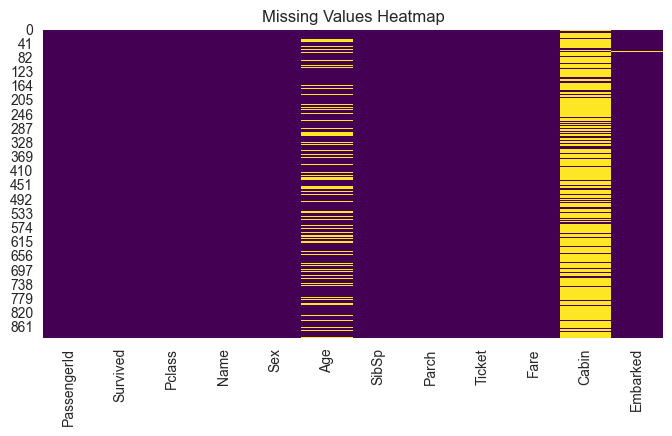

In [11]:
#check missing values
print("Missing Values:")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_percent})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [12]:
#cleaning data
df_clean = df.copy()
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)
df_clean.drop('Cabin', axis=1, inplace=True)
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)
print("Missing values after cleaning:")
print(df_clean.isnull().sum().sum())

Missing values after cleaning:
0


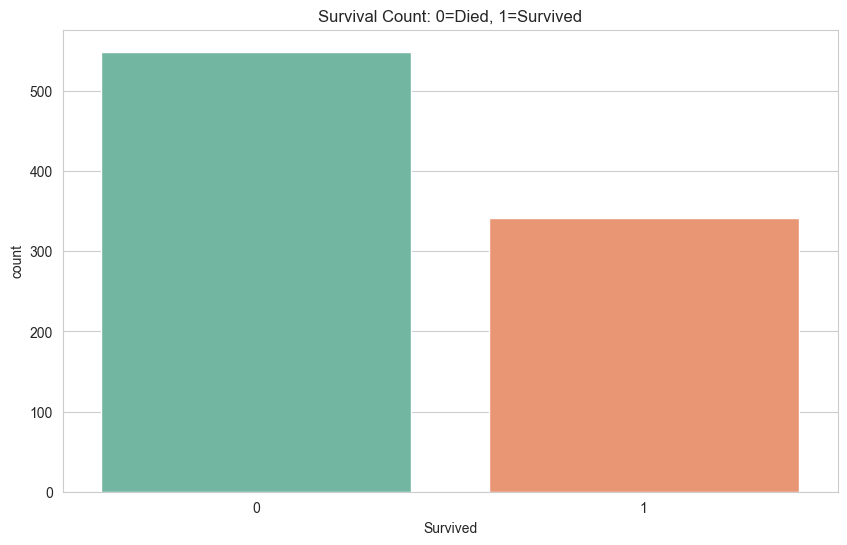

Survival Rate: 38.38%


In [13]:
#survival count plot
sns.countplot(data=df_clean, x='Survived', palette='Set2')
plt.title('Survival Count: 0=Died, 1=Survived')
plt.show()
print(f"Survival Rate: {df_clean['Survived'].mean()*100:.2f}%")

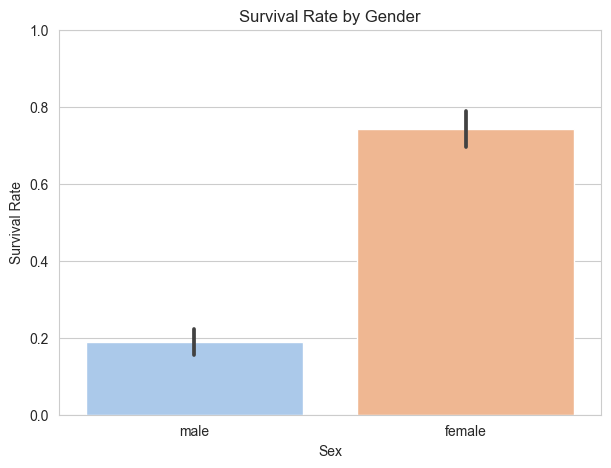

Survival Rate by Sex:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64


In [14]:
#survival v/s sex
plt.figure(figsize=(7,5))
sns.barplot(data=df_clean, x='Sex', y='Survived', palette='pastel')
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.ylim(0,1)
plt.show()
print("Survival Rate by Sex:")
print(df_clean.groupby('Sex')['Survived'].mean().round(3))

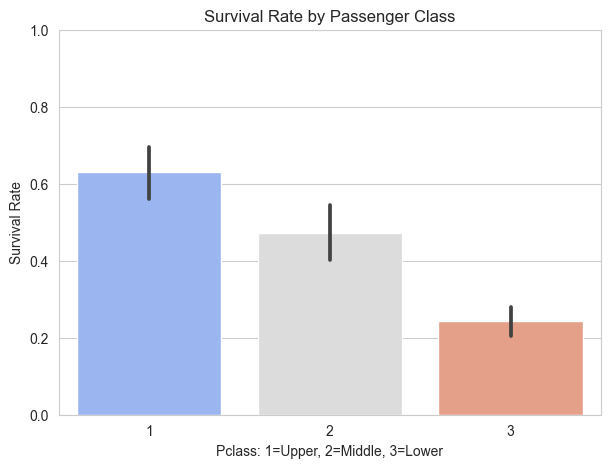

Survival Rate by Class:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


In [15]:
#survival v/s pclass
plt.figure(figsize=(7,5))
sns.barplot(data=df_clean, x='Pclass', y='Survived', palette='coolwarm')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Pclass: 1=Upper, 2=Middle, 3=Lower')
plt.ylabel('Survival Rate')
plt.ylim(0,1)
plt.show()
print("Survival Rate by Class:")
print(df_clean.groupby('Pclass')['Survived'].mean().round(3))

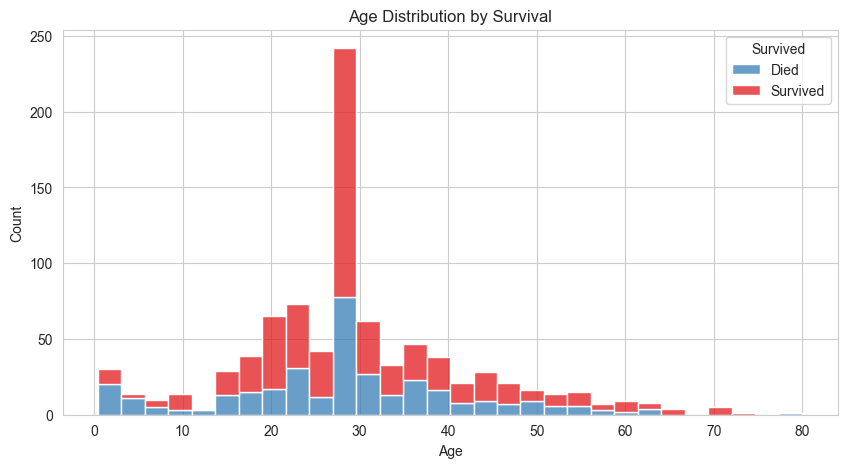

In [16]:
#age distribution
plt.figure(figsize=(10,5))
sns.histplot(data=df_clean, x='Age', hue='Survived', multiple='stack', bins=30, palette='Set1')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['Died', 'Survived'])
plt.show()

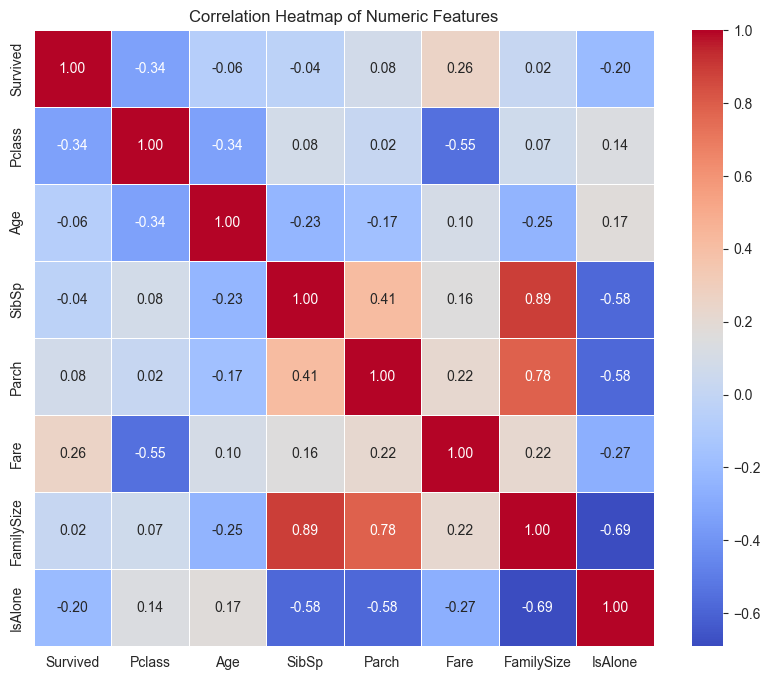

In [17]:
#correlation heatmap
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()